
https://www.nltk.org/
https://spacy.io/


In [1]:
import nltk
import string
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [9]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [5]:
text = """
The worlds of Prithvi Shaw and Ruturaj Gaikwad did not converge on Wednesday.
When Prithvi Shaw emerged from the dressing room after a four-ball duck and strode into the dug-out,
Gaikwad was already in the middle, waging a rear-guard after finding his team two wickets down without a run on the board.
The rest of Shaw’s day was reduced to cheering Gaikwad’s 91, an innings of graceful resoluteness,
the spine of Maharashtra’s 179/7, and consoling him when he slumped to a chair on the dug out after getting out.
"""

In [21]:
#Step 1 Sentence Tokenizer (Sentence tokenization is not needed anymore as word tokenization can deal with it now)
sentences = sent_tokenize(text)
print("Sentence Tokenization:\n", sentences, "\n")
print(len(sentences))

Sentence Tokenization:
 ['\nThe worlds of Prithvi Shaw and Ruturaj Gaikwad did not converge on Wednesday.', 'When Prithvi Shaw emerged from the dressing room after a four-ball duck and strode into the dug-out, \nGaikwad was already in the middle, waging a rear-guard after finding his team two wickets down without a run on the board.', 'The rest of Shaw’s day was reduced to cheering Gaikwad’s 91, an innings of graceful resoluteness, \nthe spine of Maharashtra’s 179/7, and consoling him when he slumped to a chair on the dug out after getting out.'] 

3


In [12]:
#Step 2 Word Tokenizer
words = word_tokenize(text)
print("Word Tokenization:\n", words, "\n")
print(len(words))

Word Tokenization:
 ['The', 'worlds', 'of', 'Prithvi', 'Shaw', 'and', 'Ruturaj', 'Gaikwad', 'did', 'not', 'converge', 'on', 'Wednesday', '.', 'When', 'Prithvi', 'Shaw', 'emerged', 'from', 'the', 'dressing', 'room', 'after', 'a', 'four-ball', 'duck', 'and', 'strode', 'into', 'the', 'dug-out', ',', 'Gaikwad', 'was', 'already', 'in', 'the', 'middle', ',', 'waging', 'a', 'rear-guard', 'after', 'finding', 'his', 'team', 'two', 'wickets', 'down', 'without', 'a', 'run', 'on', 'the', 'board', '.', 'The', 'rest', 'of', 'Shaw', '’', 's', 'day', 'was', 'reduced', 'to', 'cheering', 'Gaikwad', '’', 's', '91', ',', 'an', 'innings', 'of', 'graceful', 'resoluteness', ',', 'the', 'spine', 'of', 'Maharashtra', '’', 's', '179/7', ',', 'and', 'consoling', 'him', 'when', 'he', 'slumped', 'to', 'a', 'chair', 'on', 'the', 'dug', 'out', 'after', 'getting', 'out', '.'] 

103


In [16]:
# Step 3 removing stopwords
stop_words = set(stopwords.words('english'))

# print stop words

filtered_words = [word for word in words if word.lower() not in stop_words and word.isalpha()]
print("Filtered Words:\n", filtered_words, "\n")
print(len(filtered_words))

Filtered Words:
 ['worlds', 'Prithvi', 'Shaw', 'Ruturaj', 'Gaikwad', 'converge', 'Wednesday', 'Prithvi', 'Shaw', 'emerged', 'dressing', 'room', 'duck', 'strode', 'Gaikwad', 'already', 'middle', 'waging', 'finding', 'team', 'two', 'wickets', 'without', 'run', 'board', 'rest', 'Shaw', 'day', 'reduced', 'cheering', 'Gaikwad', 'innings', 'graceful', 'resoluteness', 'spine', 'Maharashtra', 'consoling', 'slumped', 'chair', 'dug', 'getting'] 

41


In [17]:
#Step 4. Stemming getting root words. (No need to use Stemminizer anymore as it is old technique)
ps = PorterStemmer()
stemmed_words = [ps.stem(word) for word in filtered_words]
print("Stemmed Words:\n", stemmed_words, "\n")
print(len(stemmed_words))

Stemmed Words:
 ['world', 'prithvi', 'shaw', 'ruturaj', 'gaikwad', 'converg', 'wednesday', 'prithvi', 'shaw', 'emerg', 'dress', 'room', 'duck', 'strode', 'gaikwad', 'alreadi', 'middl', 'wage', 'find', 'team', 'two', 'wicket', 'without', 'run', 'board', 'rest', 'shaw', 'day', 'reduc', 'cheer', 'gaikwad', 'inning', 'grace', 'resolut', 'spine', 'maharashtra', 'consol', 'slump', 'chair', 'dug', 'get'] 

41


In [19]:
lemmatizer = WordNetLemmatizer() #Lemmatizer is used instead of Stemmer.
lemmatized_words = [lemmatizer.lemmatize(word.lower()) for word in filtered_words]
print("Lemmatized Words:\n", lemmatized_words, "\n")
print(len(lemmatized_words))

Lemmatized Words:
 ['world', 'prithvi', 'shaw', 'ruturaj', 'gaikwad', 'converge', 'wednesday', 'prithvi', 'shaw', 'emerged', 'dressing', 'room', 'duck', 'strode', 'gaikwad', 'already', 'middle', 'waging', 'finding', 'team', 'two', 'wicket', 'without', 'run', 'board', 'rest', 'shaw', 'day', 'reduced', 'cheering', 'gaikwad', 'inning', 'graceful', 'resoluteness', 'spine', 'maharashtra', 'consoling', 'slumped', 'chair', 'dug', 'getting'] 

41


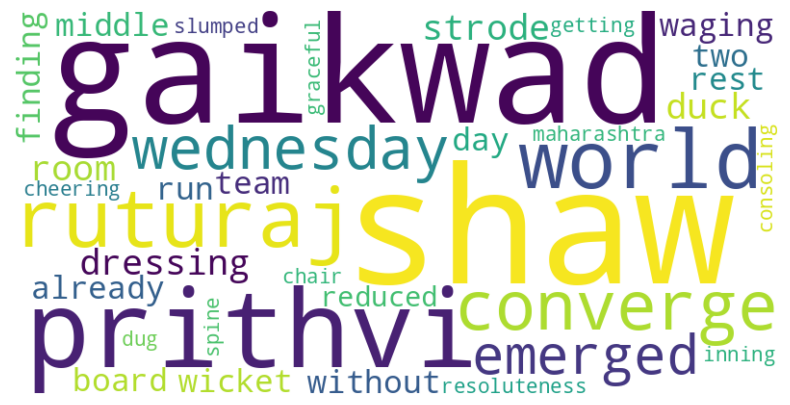

In [20]:
# Step 6. WordCloud (visualize what this document is taking about)

wordcloud_text = ' '.join(lemmatized_words)
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(wordcloud_text)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

NER like BODMAS.

Peter is working in Google from 2025.

It gives more weightage to certain words.

This whole tecnique can be used in Sentiment Analysis.

In [22]:
!pip install spacy

Use Spacy instead of nltk as it has better support. Spacy is developed by Standford University.

In [24]:
import spacy
nlp = spacy.load('en_core_web_sm')

In [25]:
doc = nlp(text)
doc


The worlds of Prithvi Shaw and Ruturaj Gaikwad did not converge on Wednesday. 
When Prithvi Shaw emerged from the dressing room after a four-ball duck and strode into the dug-out, 
Gaikwad was already in the middle, waging a rear-guard after finding his team two wickets down without a run on the board. 
The rest of Shaw’s day was reduced to cheering Gaikwad’s 91, an innings of graceful resoluteness, 
the spine of Maharashtra’s 179/7, and consoling him when he slumped to a chair on the dug out after getting out.

In [26]:
# Sentence Tokenizer
for sent in doc.sents:
    print(sent)


The worlds of Prithvi Shaw and Ruturaj Gaikwad did not converge on Wednesday. 

When Prithvi Shaw emerged from the dressing room after a four-ball duck and strode into the dug-out, 
Gaikwad was already in the middle, waging a rear-guard after finding his team two wickets down without a run on the board. 

The rest of Shaw’s day was reduced to cheering Gaikwad’s 91, an innings of graceful resoluteness, 
the spine of Maharashtra’s 179/7, and consoling him when he slumped to a chair on the dug out after getting out.



In [27]:
# Word Tokenizer
for sent in doc.sents:
    for word in sent:
        print(word)



The
worlds
of
Prithvi
Shaw
and
Ruturaj
Gaikwad
did
not
converge
on
Wednesday
.


When
Prithvi
Shaw
emerged
from
the
dressing
room
after
a
four
-
ball
duck
and
strode
into
the
dug
-
out
,


Gaikwad
was
already
in
the
middle
,
waging
a
rear
-
guard
after
finding
his
team
two
wickets
down
without
a
run
on
the
board
.


The
rest
of
Shaw
’s
day
was
reduced
to
cheering
Gaikwad
’s
91
,
an
innings
of
graceful
resoluteness
,


the
spine
of
Maharashtra
’s
179/7
,
and
consoling
him
when
he
slumped
to
a
chair
on
the
dug
out
after
getting
out
.




In [32]:
for token in doc:
  if not token.is_stop and token.is_alpha and not token.is_punct and not token.is_space :
    print(f"word : {token} | Lemma : {token.lemma_}")

word : worlds | Lemma : world
word : Prithvi | Lemma : Prithvi
word : Shaw | Lemma : Shaw
word : Ruturaj | Lemma : Ruturaj
word : Gaikwad | Lemma : Gaikwad
word : converge | Lemma : converge
word : Wednesday | Lemma : Wednesday
word : Prithvi | Lemma : Prithvi
word : Shaw | Lemma : Shaw
word : emerged | Lemma : emerge
word : dressing | Lemma : dressing
word : room | Lemma : room
word : ball | Lemma : ball
word : duck | Lemma : duck
word : strode | Lemma : stride
word : dug | Lemma : dug
word : Gaikwad | Lemma : Gaikwad
word : middle | Lemma : middle
word : waging | Lemma : wage
word : rear | Lemma : rear
word : guard | Lemma : guard
word : finding | Lemma : find
word : team | Lemma : team
word : wickets | Lemma : wicket
word : run | Lemma : run
word : board | Lemma : board
word : rest | Lemma : rest
word : Shaw | Lemma : Shaw
word : day | Lemma : day
word : reduced | Lemma : reduce
word : cheering | Lemma : cheer
word : Gaikwad | Lemma : Gaikwad
word : innings | Lemma : innings
word : 